# MiniTFM - EDA
Thyroid disease records supplied by the Garavan Institute and J. Ross Quinlan, New South Wales Institute, Syndney, Australia - 1987

This directory contains the latest version of an archive of thyroid diagnoses obtained from the Garvan Institute, consisting of 9172 records from 1984 to early 1987.  Each record looks like

	(29 attribute values), diagnoses [record identification]

The attributes are given in order and separated by commas. Unknown attribute values are indicated by question marks. The attributes are:

	Attribute Name			Possible Values
	--------------			---------------
	age:				continuous.
	sex:				M, F.
	on thyroxine:			f, t.
	query on thyroxine:		f, t.
	on antithyroid medication:	f, t.
	sick:				f, t.
	pregnant:			f, t.
	thyroid surgery:		f, t.
	I131 treatment:			f, t.
	query hypothyroid:		f, t.
	query hyperthyroid:		f, t.
	lithium:			f, t.
	goitre:				f, t.
	tumor:				f, t.
	hypopituitary:			f, t.
	psych:				f, t.
	TSH measured:			f, t.
	TSH:				continuous.
	T3 measured:			f, t.
	T3:				continuous.
	TT4 measured:			f, t.
	TT4:				continuous.
	T4U measured:			f, t.
	T4U:				continuous.
	FTI measured:			f, t.
	FTI:				continuous.
	TBG measured:			f, t.
	TBG:				continuous.
	referral source:		WEST, STMW, SVHC, SVI, SVHD, other.

The diagnosis consists of a string of letters indicating diagnosed conditions. A diagnosis "-" indicates no condition requiring comment. A diagnosis of the form "X|Y" is interpreted as "consistent with X, but more likely Y". The conditions are divided into groups where each group corresponds to a class of comments.

		Letter	Diagnosis
		------	---------

	hyperthyroid conditions:

		A	hyperthyroid
		B	T3 toxic
		C	toxic goitre
		D	secondary toxic

	hypothyroid conditions:

		E	hypothyroid
		F	primary hypothyroid
		G	compensated hypothyroid
		H	secondary hypothyroid

	binding protein:

		I	increased binding protein
		J	decreased binding protein

	general health:

		K	concurrent non-thyroidal illness

	replacement therapy:

		L	consistent with replacement therapy
		M	underreplaced
		N	overreplaced

	antithyroid treatment:

		O	antithyroid drugs
		P	I131 treatment
		Q	surgery

	miscellaneous:

		R	discordant assay results
		S	elevated TBG
		T	elevated thyroid hormones

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [2]:
column_names = [
    "age", "sex", "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication", "sick", "pregnant",
    "thyroid_surgery", "I131_treatment", "query_hypothyroid", "query_hyperthyroid", "lithium", "goitre",
    "tumor", "hypopituitary", "psych", "TSH_measured", "TSH", "T3_measured", "T3", "TT4_measured", "TT4",
    "T4U_measured", "T4U", "FTI_measured", "FTI", "TBG_measured", "TBG", "referral_source", "diagnosis"
]

df = pd.read_csv("thyroid0387.data", names=column_names, na_values="?", dtype=str)

df["diagnosis"] = df["diagnosis"].str.extract(r"^([^ \[\|]+)")

for col in ["age", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

bool_cols = [
    "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication",
    "sick", "pregnant", "thyroid_surgery", "I131_treatment", "query_hypothyroid",
    "query_hyperthyroid", "lithium", "goitre", "tumor", "hypopituitary", "psych",
    "TSH_measured", "T3_measured", "TT4_measured", "T4U_measured", "FTI_measured", "TBG_measured"
]

for col in bool_cols:
    df[col] = df[col].map({'t': True, 'f': False, '?': pd.NA})
df[bool_cols] = df[bool_cols].astype("bool")

df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,diagnosis
0,29,F,False,False,False,False,False,False,False,True,...,False,NaN,False,NaN,False,NaN,False,NaN,other,-
1,29,F,False,False,False,False,False,False,False,False,...,True,128.0,False,NaN,False,NaN,False,NaN,other,-
2,41,F,False,False,False,False,False,False,False,False,...,False,NaN,False,NaN,False,NaN,True,11.0,other,-
3,36,F,False,False,False,False,False,False,False,False,...,False,NaN,False,NaN,False,NaN,True,26.0,other,-
4,32,F,False,False,False,False,False,False,False,False,...,False,NaN,False,NaN,False,NaN,True,36.0,other,S


In [3]:
df.describe()

,age,TSH,T3,TT4,T4U,FTI,TBG
count,9172.000000,8330.000000,6568.000000,8730.000000,8363.000000,8370.000000,349.000000
mean,73.555822,5.218403,1.970629,108.700305,0.976056,113.640746,29.870057
std,1183.976718,24.184006,0.887579,37.522670,0.200360,41.551650,21.080504
min,1.000000,0.005000,0.050000,2.000000,0.170000,1.400000,0.100000
25%,37.000000,0.460000,1.500000,87.000000,0.860000,93.000000,21.000000
50%,55.000000,1.400000,1.900000,104.000000,0.960000,109.000000,26.000000
75%,68.000000,2.700000,2.300000,126.000000,1.065000,128.000000,31.000000
max,65526.000000,530.000000,18.000000,600.000000,2.330000,881.000000,200.000000


In [4]:
(df == '?').sum().sort_values(ascending=False)

age                          0
sex                          0
referral_source              0
TBG                          0
TBG_measured                 0
FTI                          0
FTI_measured                 0
T4U                          0
T4U_measured                 0
TT4                          0
TT4_measured                 0
T3                           0
T3_measured                  0
TSH                          0
TSH_measured                 0
psych                        0
hypopituitary                0
tumor                        0
goitre                       0
lithium                      0
query_hyperthyroid           0
query_hypothyroid            0
I131_treatment               0
thyroid_surgery              0
pregnant                     0
sick                         0
on_antithyroid_medication    0
query_on_thyroxine           0
on_thyroxine                 0
diagnosis                    0
dtype: int64

In [5]:
df = df[df["age"] <= 120]

In [6]:
print("Shape:", df.shape)
print("\nColumn Data Types:\n", df.dtypes)
print("\nDiagnosis Value Counts:\n", df["diagnosis"].value_counts(dropna=False))
print("\nMissing Values Per Column:\n", df.isna().sum())

Shape: (9168, 30)

Column Data Types:
 age                            int64
sex                           object
on_thyroxine                    bool
query_on_thyroxine              bool
on_antithyroid_medication       bool
sick                            bool
pregnant                        bool
thyroid_surgery                 bool
I131_treatment                  bool
query_hypothyroid               bool
query_hyperthyroid              bool
lithium                         bool
goitre                          bool
tumor                           bool
hypopituitary                   bool
psych                           bool
TSH_measured                    bool
TSH                          float64
T3_measured                     bool
T3                           float64
TT4_measured                    bool
TT4                          float64
T4U_measured                    bool
T4U                          float64
FTI_measured                    bool
FTI                          float64

After loading the thyroid0387 dataset, categorical boolean attributes originally encoded as 't' and 'f' were mapped to Python logical values (True, False).

The target variable diagnosis comprises 29 unique string codes. These represent either single-letter or composite thyroid condition diagnoses. The dataset contains 9,172 observations and 30 features. To align with standard practice and facilitate more interpretable analysis, we will introduce a new variable that groups the diagnosis values according to the categories defined in the dataset documentation (see the chart at the top of this notebook). Composite diagnoses (e.g., GK) were resolved using the first letter, which typically denotes the primary condition.

In [7]:
diagnosis_groups = {
    "hyperthyroid": ["A", "B", "C", "D"],
    "hypothyroid": ["E", "F", "G", "H"],
    "binding_protein": ["I", "J"],
    "general_health": ["K"],
    "replacement_therapy": ["L", "M", "N"],
    "antithyroid_treatment": ["O", "P", "Q"],
    "misc": ["R", "S", "T"],
    "normal": ["-"]
}

letter_to_group = {
    letter: group
    for group, letters in diagnosis_groups.items()
    for letter in letters
}

df["diagnosis_group"] = df["diagnosis"].str[0].map(letter_to_group)
print("\nDiagnosis Group Value Counts:\n", df["diagnosis_group"].value_counts(dropna=False))


Diagnosis Group Value Counts:
 diagnosis_group
normal                   6767
hypothyroid               667
general_health            447
binding_protein           376
replacement_therapy       355
misc                      281
hyperthyroid              241
antithyroid_treatment      34
Name: count, dtype: int64


In [8]:
df[(df["sex"] == "M") & (df["pregnant"] == True)].shape[0]

0

In [9]:
df = df[df["sex"].notna()]

In [10]:
df = pd.get_dummies(df, columns=["sex"], prefix="sex", drop_first=True)

In [11]:
lab_tests = ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]

for test in lab_tests:
    measured_flag = f"{test}_measured"
    missing_when_measured = df[(df[test].isna()) & (df[measured_flag] == True)].shape[0]
    print(f"{test}: Missing even when measured → {missing_when_measured} rows")

TSH: Missing even when measured → 0 rows
T3: Missing even when measured → 0 rows
TT4: Missing even when measured → 0 rows
T4U: Missing even when measured → 0 rows
FTI: Missing even when measured → 0 rows
TBG: Missing even when measured → 0 rows


In [12]:
for test in lab_tests:
    measured_flag = f"{test}_measured"
    df[f"{test}_value"] = df.apply(
        lambda row: row[test] if row[measured_flag] else np.nan,
        axis=1
    )

In [13]:
df = pd.get_dummies(df, columns=["referral_source"], prefix="ref", drop_first=False)

In [14]:
measured_flags = [f"{test}_measured" for test in lab_tests]

columns_to_drop = lab_tests + measured_flags
df.drop(columns=columns_to_drop, inplace=True)

The sex variable was recoded into a Boolean field named is_male. Prior to this transformation, 307 records (approximately 3.3% of the dataset) contained missing values for sex. Given the relatively small proportion and the uncertainty involved in reliably imputing gender from other features (we checked for pregnant to see if we could save some), these records were excluded from the dataset to preserve data integrity during analysis.

For laboratory measurements such as TSH, T3, TT4, T4U, FTI, and TBG, each value is accompanied by a corresponding _measured flag indicating whether the test was performed. We confirmed that missing values in these features occurred only when the respective _measured flag was False. Based on this, we consolidated each measurement into a unified variable that retains the actual test result when available, and uses NaN when the test was not performed, this nulls therefore, are not missing values per se, but indicate that we do not have that information for that given test and record.

The referral_source, which represents the origin of the patient referral (e.g., hospitals or clinics), was treated as a nominal categorical variable. Since it has no inherent ordering, we applied one-hot encoding to represent each referral source as a separate binary indicator variable.

In [15]:
print("Shape:", df.shape)
print("\nColumn Data Types:\n", df.dtypes)
print("\nDiagnosis Value Counts:\n", df["diagnosis"].value_counts(dropna=False))
print("\nMissing Values Per Column:\n", df.isna().sum())

Shape: (8861, 30)

Column Data Types:
 age                            int64
on_thyroxine                    bool
query_on_thyroxine              bool
on_antithyroid_medication       bool
sick                            bool
pregnant                        bool
thyroid_surgery                 bool
I131_treatment                  bool
query_hypothyroid               bool
query_hyperthyroid              bool
lithium                         bool
goitre                          bool
tumor                           bool
hypopituitary                   bool
psych                           bool
diagnosis                     object
diagnosis_group               object
sex_M                           bool
TSH_value                    float64
T3_value                     float64
TT4_value                    float64
T4U_value                    float64
FTI_value                    float64
TBG_value                    float64
ref_STMW                        bool
ref_SVHC                        bool

In [16]:
def plot_univariate_distribution(df, column, bins=30):
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(df[column].dropna(), kde=True, bins=bins, ax=axs[0], color="blue")
    axs[0].set_title(f"Histogram of {column}")
    
    sns.boxplot(x=df[column], ax=axs[1], color="orange")
    axs[1].set_title(f"Boxplot of {column}")
    
    plt.tight_layout()
    plt.show()

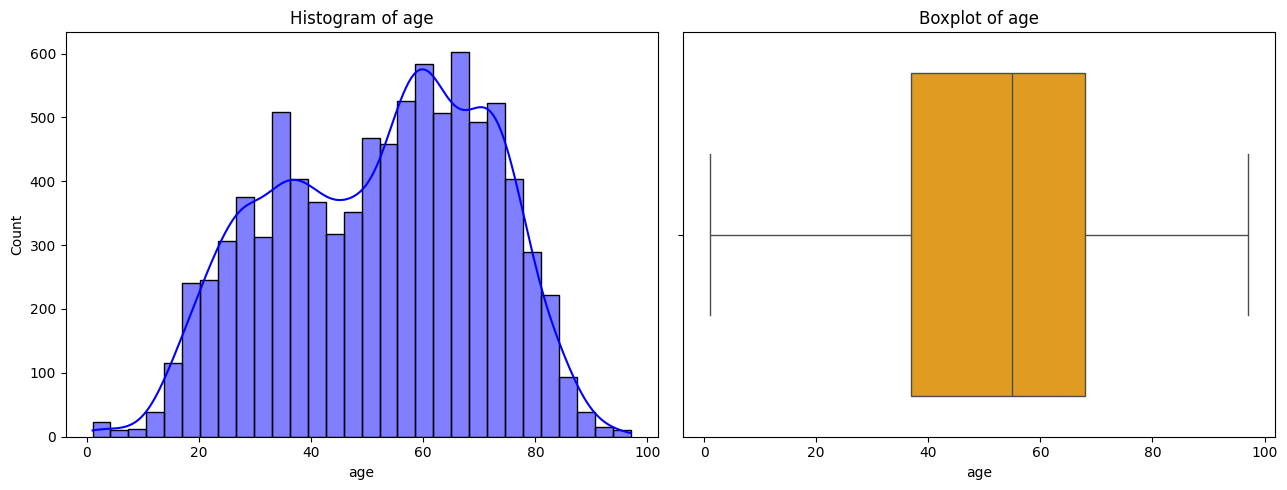

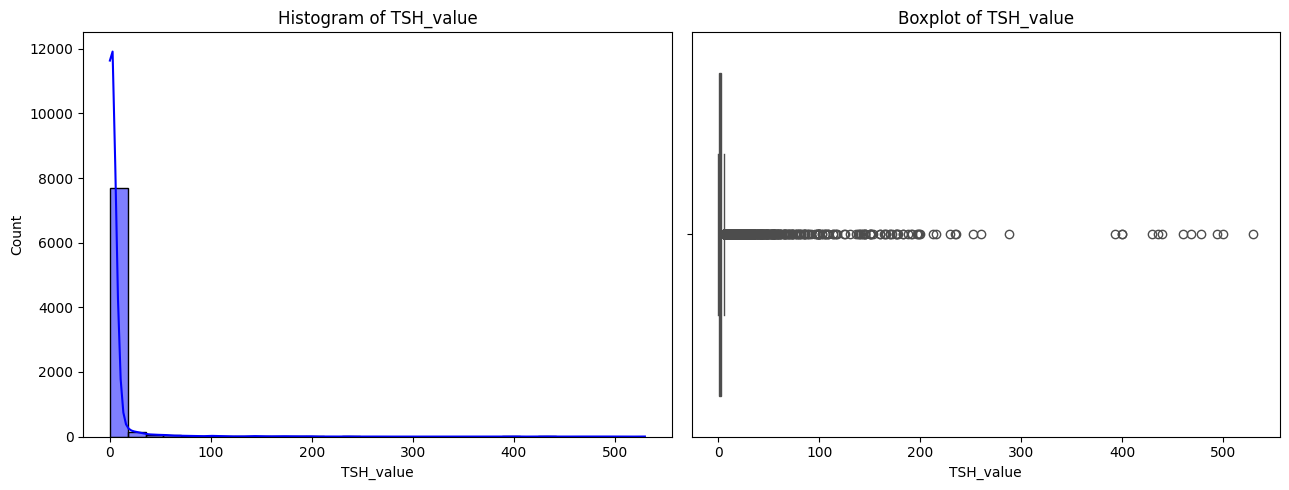

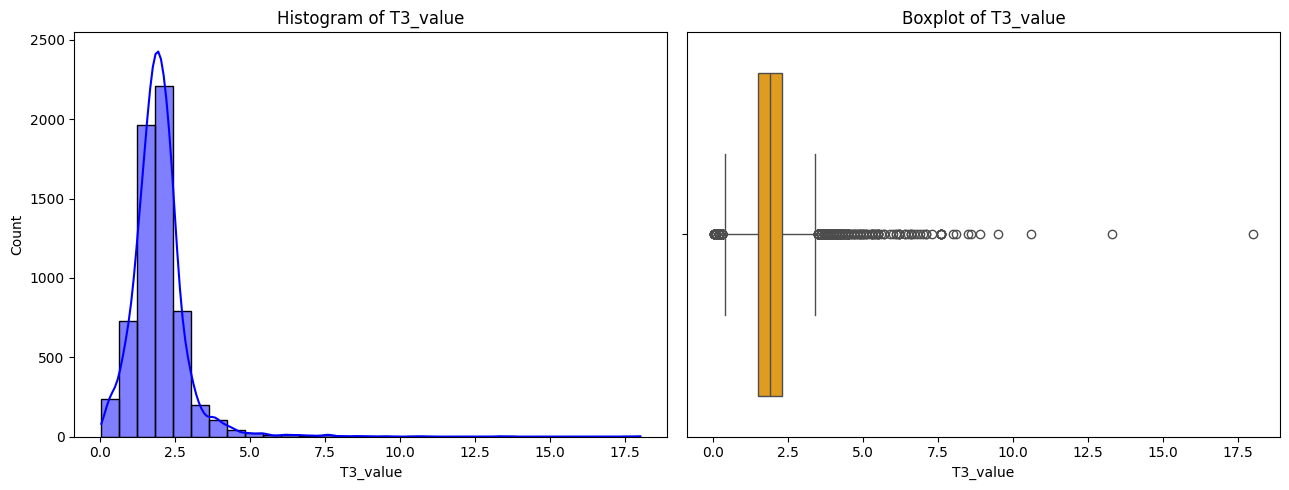

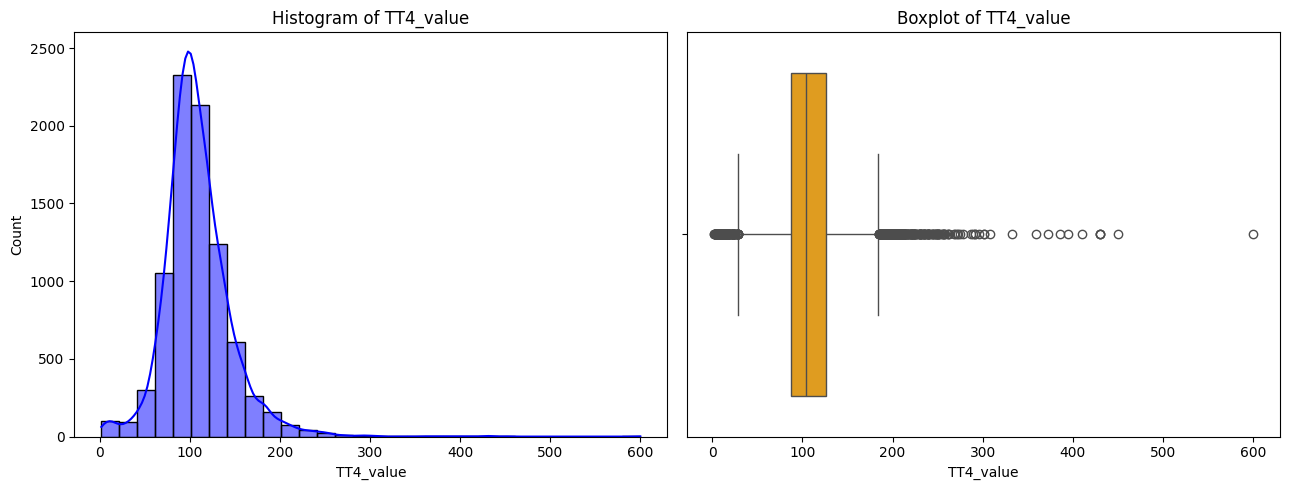

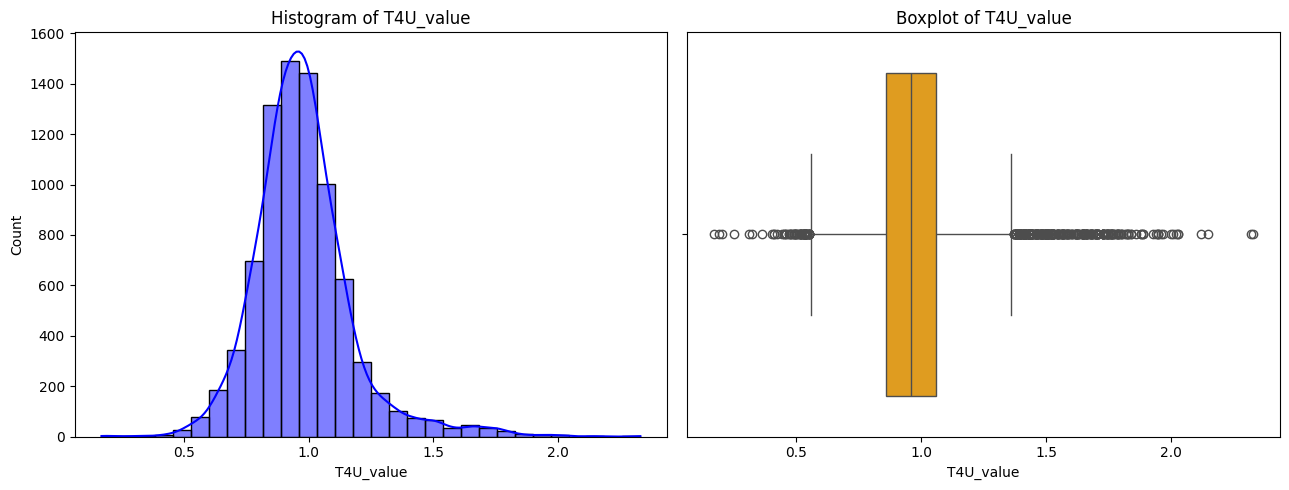

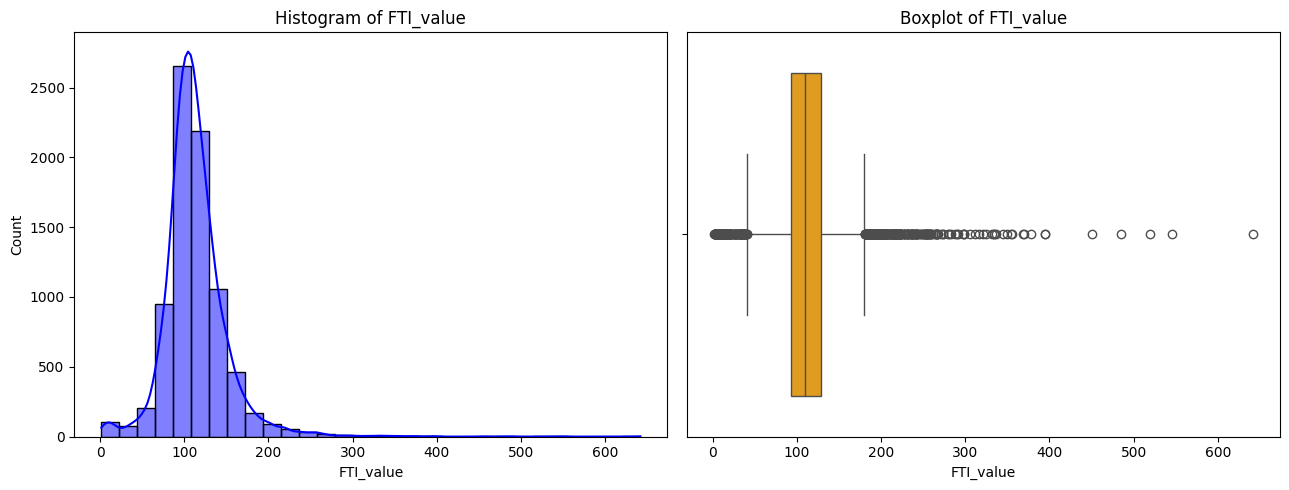

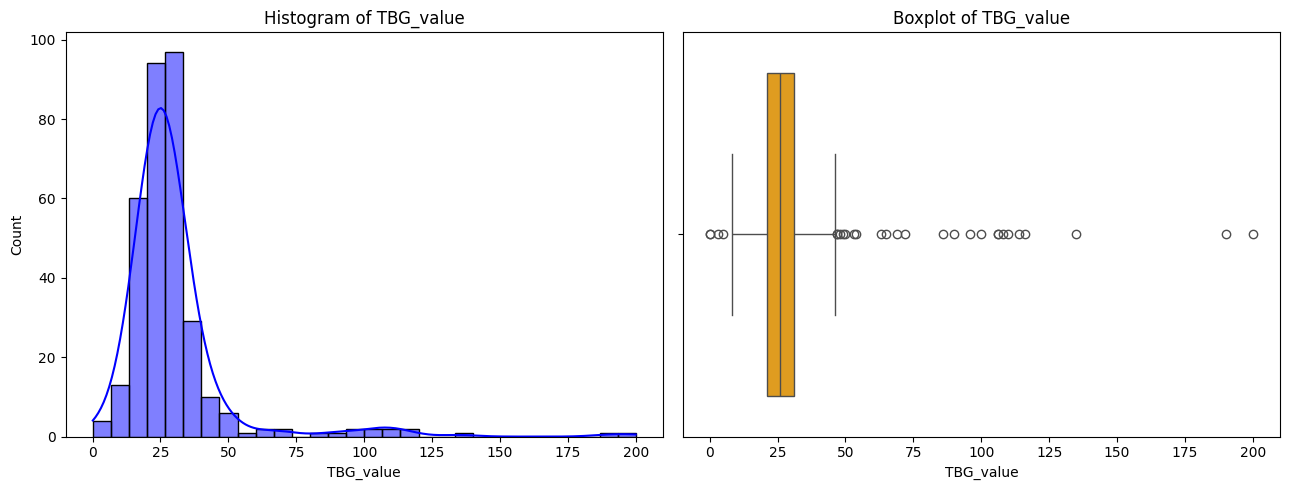

In [17]:
numeric_features = ["age", "TSH_value", "T3_value", "TT4_value", "T4U_value", "FTI_value", "TBG_value"]

for col in numeric_features:
    plot_univariate_distribution(df, col)

The distribution of patient age follows a right-skewed shape, with a dense concentration between approximately 30 and 70 years. A few observations existed above 120 years, which are considered impossible and likely the result of data entry errors or placeholder values. These were excluded from the dataset prior to analysis.

TSH (Thyroid Stimulating Hormone) exhibits a highly right-skewed distribution with a sharp peak near zero and a long tail extending beyond 500. While this includes extreme outliers, we decided not to apply any upper-bound cutoff. Upon reviewing literature and community forum discussions, it is clear that, although rare, exceptionally high TSH levels have been observed in cases of severe hypothyroidism or lab errors. For the purpose of analysis, we chose to preserve these extreme values rather than exclude what may be diagnostically significant edge cases.

The T3 distribution is unimodal and fairly symmetrical, centered around 2.0–2.5. A number of outliers exist above 5, though their density is relatively low. No values appear erroneous based on clinical expectations, so all are retained.

TT4 displays a bell-shaped distribution with a moderate right skew and a central mass near 100 µg/dL. Extreme values again extend beyond 500, but align with known medical cases of thyroid dysfunction.

T4U (Thyroxine Uptake) is normally distributed and tightly concentrated around 1.0, consistent with its expected range in thyroid function tests. While a few outliers are observed, they remain within a plausible clinical window.

FTI (Free Thyroxine Index) shows a distribution pattern similar to TT4, with a primary cluster near 100 and a gradual decline into high-value outliers.

TBG (Thyroxine-Binding Globulin) has a very sparse distribution due to very few entries. However, the available values appear right-skewed and range from 0 to ~200. No cutoffs were applied due to the limited sample size and to retain all potential signal.

Overall, the distributions exhibit a mix of symmetric, bell-shaped patterns (e.g., T3, T4U) and highly skewed ones (e.g., TSH, TBG), which is typical in clinical datasets. All numerical values were retained in full to preserve rare but potentially informative extremes.

In [18]:
def horizontal_boxplot_by_booleans(df, lab_col, bool_cols):
    data = []
    for feature in bool_cols:
        subset = df[[feature, lab_col]].dropna()
        subset = subset.rename(columns={feature: "Flag", lab_col: "Value"})
        subset["Feature"] = feature
        data.append(subset)
    full = pd.concat(data)

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=full, x="Value", y="Feature", hue="Flag", dodge=True)
    plt.title(f"{lab_col} by Boolean Features")
    plt.xlabel(lab_col)
    plt.ylabel("Boolean Feature")
    plt.legend(title="Flag")
    plt.show()

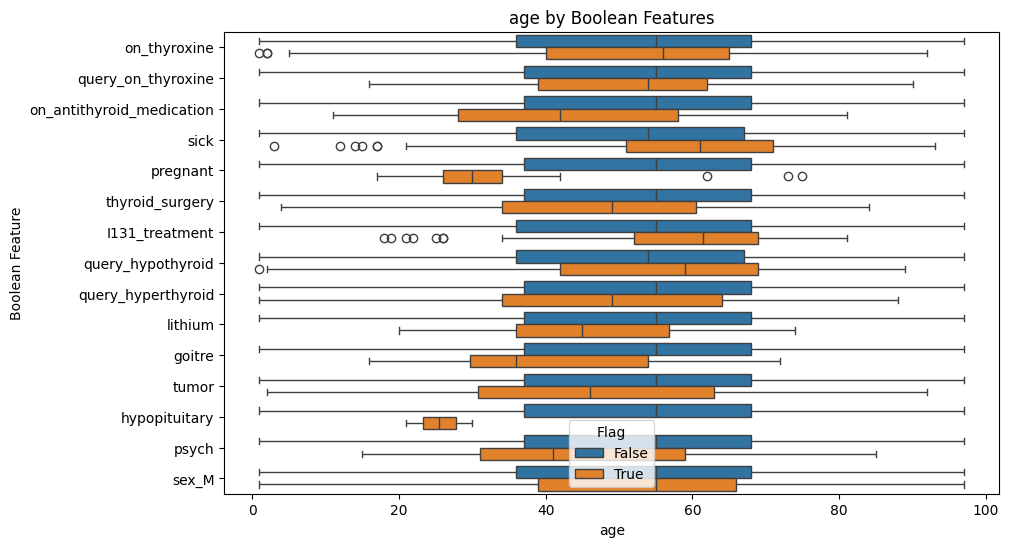

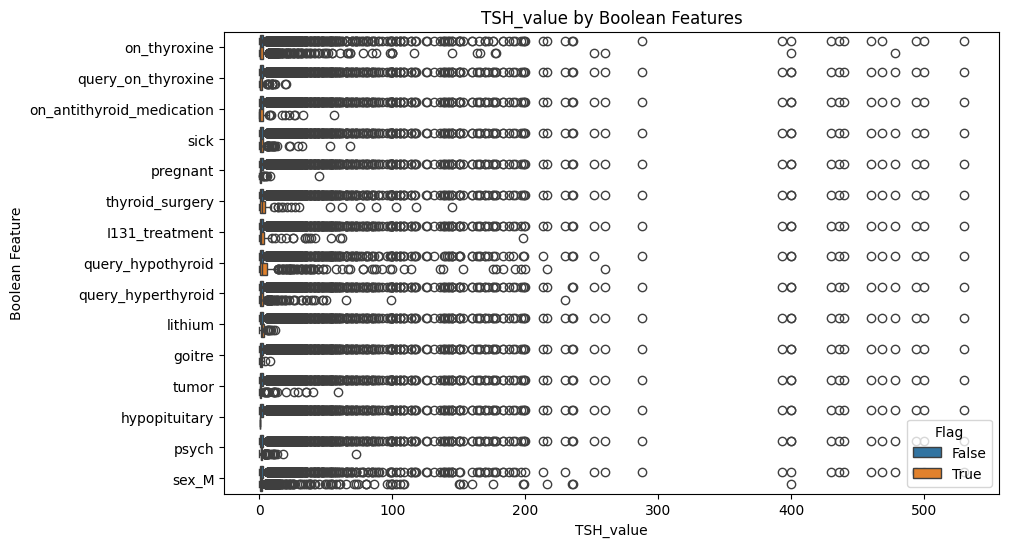

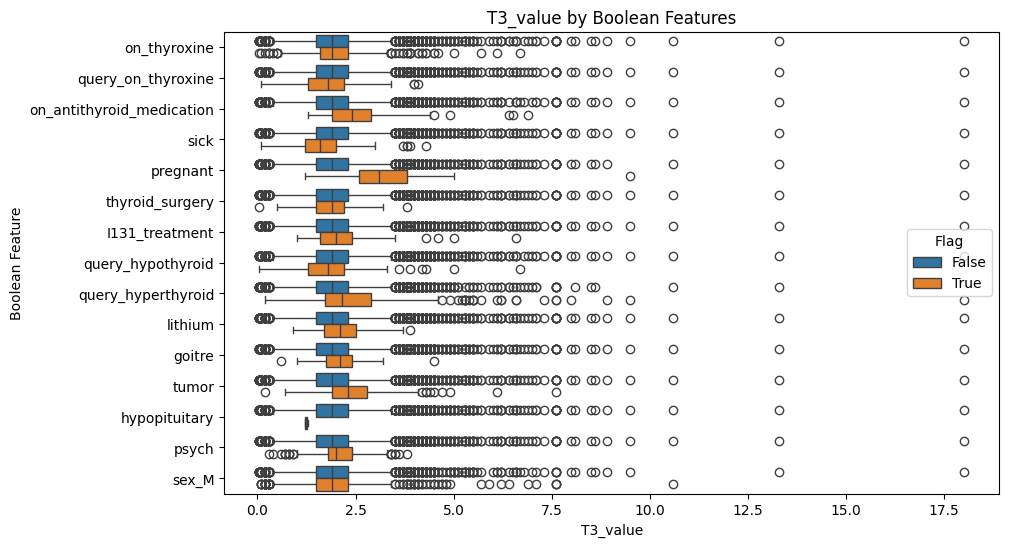

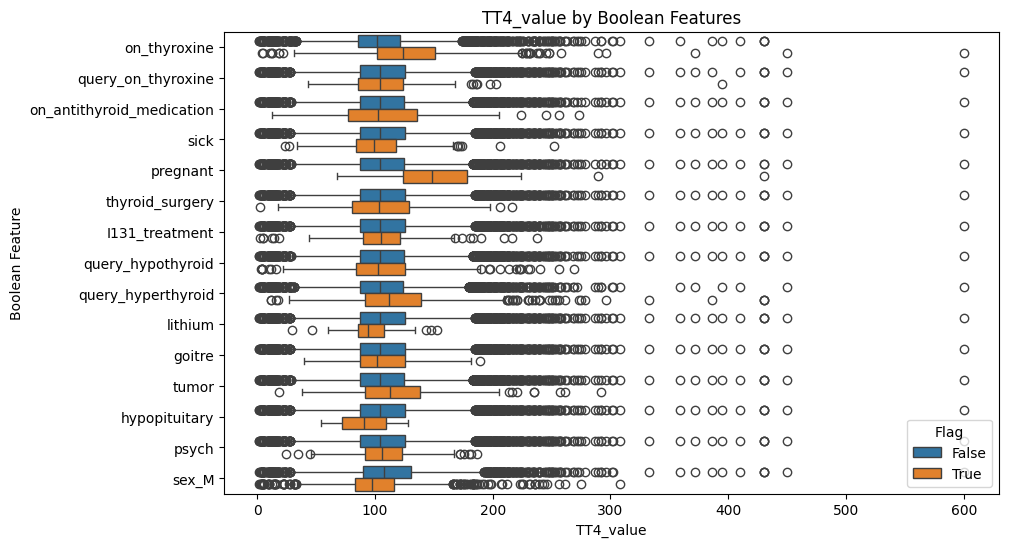

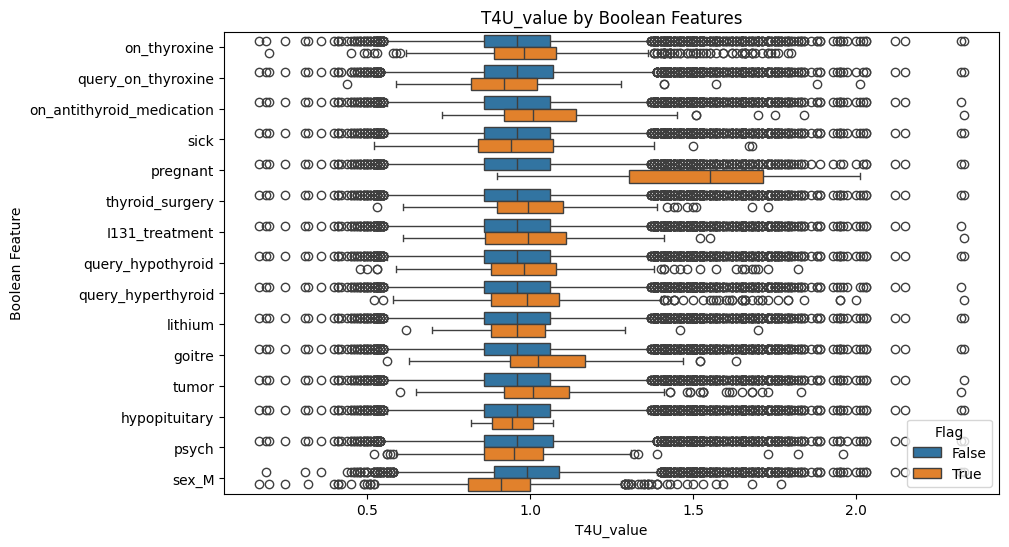

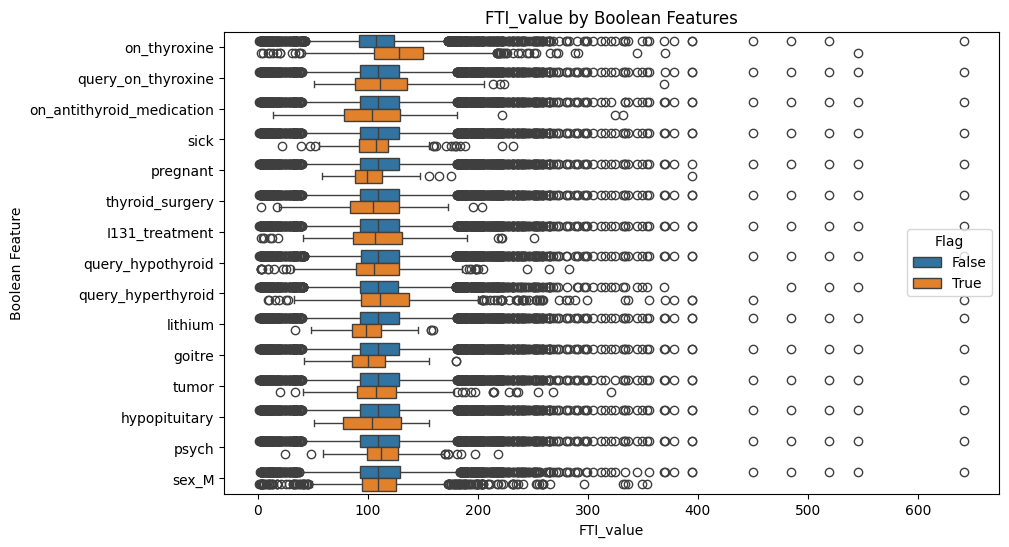

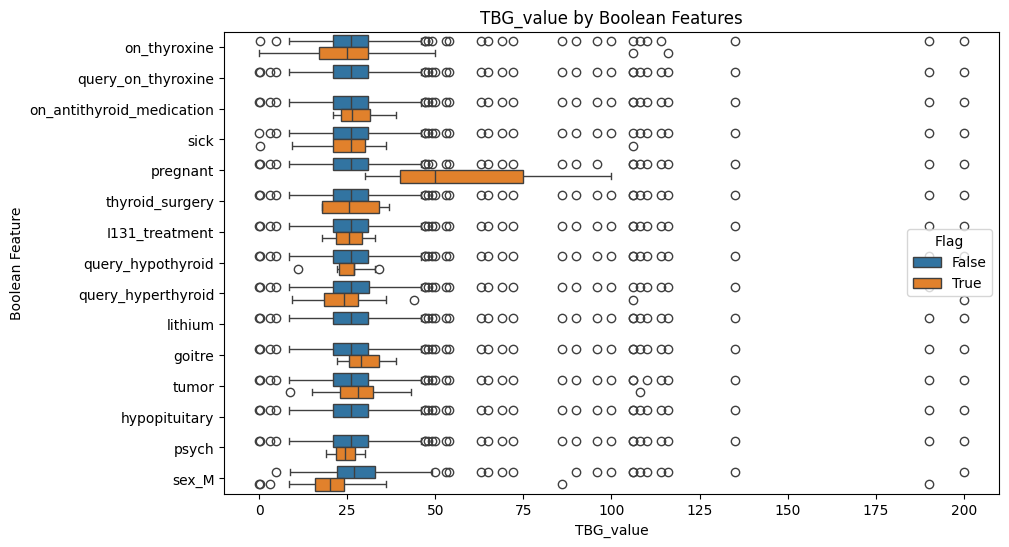

In [19]:
bool_features = ["on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication", "sick","pregnant", "thyroid_surgery", "I131_treatment", "query_hypothyroid","query_hyperthyroid", "lithium", "goitre", "tumor", "hypopituitary","psych", "sex_M"]

for lab in numeric_features:
    horizontal_boxplot_by_booleans(df, lab, bool_features)

Due to the presence of extreme outliers, in features like TSH_value, FTI_value, and TT4_value, most boxplots appear cramped toward the lower value range. These extreme values may result from data entry errors, rare but valid medical cases, or measurement anomalies. For now, they are retained in the analysis to preserve diagnostic nuance. However, they may be capped or handled differently during model preparation for better scaling and performance. Several features display clear shifts in hormone levels depending on certain binary attributes, which align with known clinical behavior.

##### on_thyroxine & on_antithyroid_medication
Patients on thyroxine tend to have lower TSH levels, as expected from thyroid hormone replacement therapy suppressing TSH via negative feedback. FTI and TT4 distributions are generally higher among those on medication, consistent with hormone supplementation. This validates that treatment flags correspond with physiological effects in the data.

##### query_on_thyroxine, query_hypothyroid, query_hyperthyroid
In some, like query_hypothyroid, there's slight elevation in TSH values compared to the rest, consistent with suspected hypothyroidism.

##### sick
Individuals flagged as generally sick (non-thyroidal illness) show a downward shift in T3 values. This is clinically consistent: in euthyroid sick syndrome, T3 is often reduced due to peripheral conversion disruption.

##### pregnant
Much higher TT4, TBG, and T4U in pregnant patients, which aligns with pregnancy-induced elevation of thyroxine-binding globulin and overall thyroid activity.

##### psych & hypopituitary
Both flags show suppressed TSH, TT4, and FTI levels when True, especially for hypopituitary. This suggests central hypothyroidism, where the pituitary fails to stimulate the thyroid.

##### thyroid_surgery & I131_treatment
These interventions are associated with lower TSH (if under replacement therapy) and higher FTI in some cases, consistent with post-treatment monitoring or overreplacement. These variables might reflect different post-treatment outcomes (some hyperfunction, some suppression).

##### tumor, goitre, lithium
Goitre and tumor flags show minimal shifts, likely due to heterogeneous cases (goitres can be hypo, hyper, or euthyroid). Lithium shows slightly elevated TSH, in line with its known effect of impairing thyroid hormone synthesis.

##### sex_M
Males show slightly lower median TBG and slightly higher FTI than females, consistent with sex-based hormone and binding protein differences.

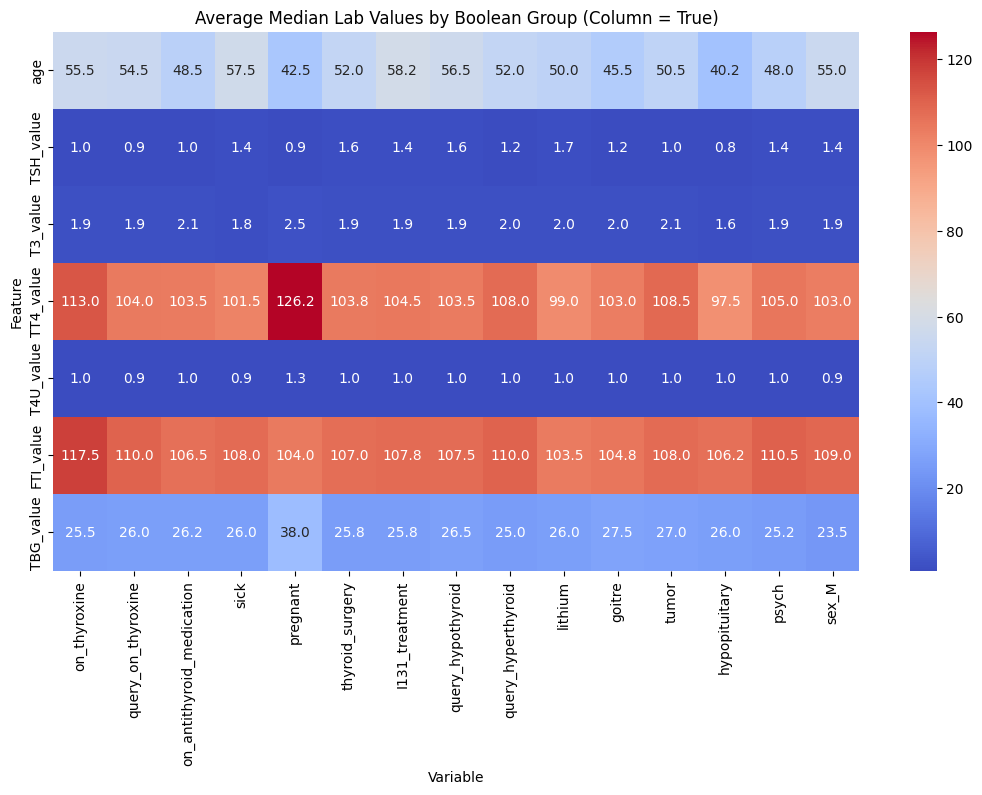

In [20]:
summary = pd.DataFrame({
    feature: df.groupby(feature)[numeric_features].median().T.mean(axis=1)
    for feature in bool_features
})

plt.figure(figsize=(13, 7))
sns.heatmap(summary, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Average Median Lab Values by Boolean Group (Column = True)")
plt.ylabel("Feature")
plt.xlabel("Variable")
plt.show()

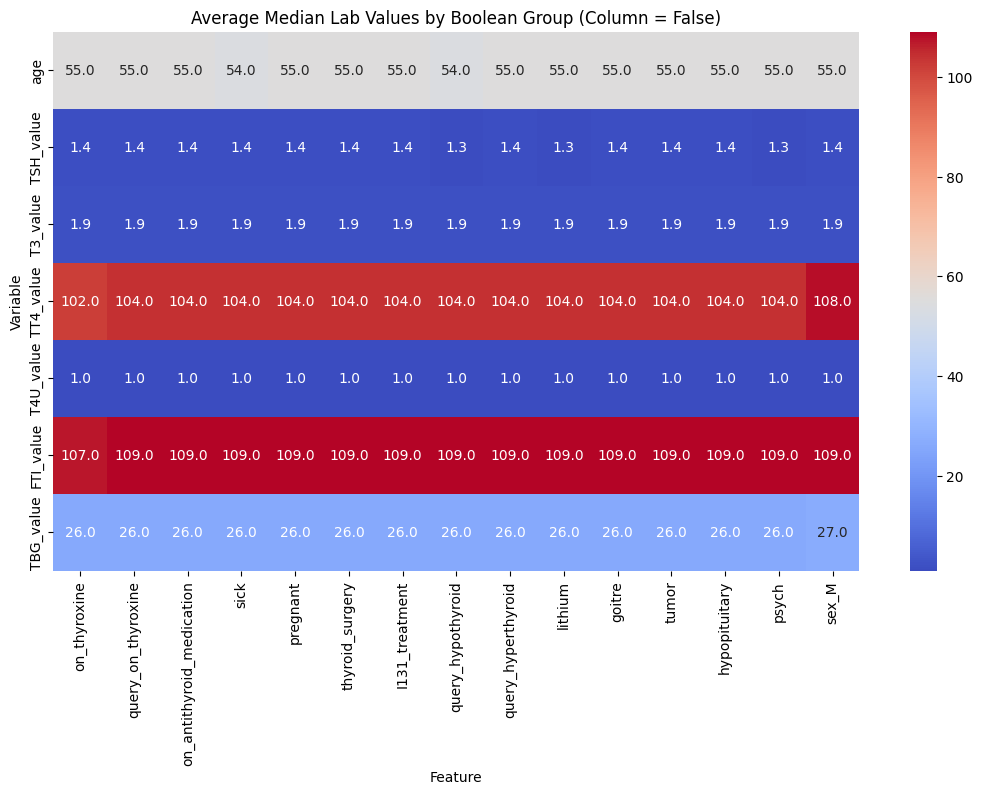

In [21]:
summary_false = pd.DataFrame({
    feature: df[df[feature] == False].groupby(feature)[numeric_features].median().T.mean(axis=1)
    for feature in bool_features
})

plt.figure(figsize=(13, 7))
sns.heatmap(summary_false, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Average Median Lab Values by Boolean Group (Column = False)")
plt.ylabel("Variable")
plt.xlabel("Feature")
plt.show()

As expected, most patterns align closely with what we’ve already seen. Pregnancy continues to stand out as a clear hormonal modulator, pregnant individuals show notably elevated levels of TT4 and TBG, reflecting changes driven by increased estrogen and liver protein synthesis. FTI also trends slightly higher in this group, likely in response to those shifts in binding proteins.

Patients on thyroxine again show the expected hormonal signature, suppressed TSH levels along with moderately elevated TT4 and FTI, consistent with exogenous hormone therapy. In contrast, those on antithyroid medication exhibit a mild reversal of this pattern, TSH is slightly elevated while T3 and FTI are lower, suggesting effective downregulation of thyroid activity.

Other features follow subtler but clinically meaningful patterns. Individuals marked as generally sick tend to show slightly lower T3 and FTI values, which reinforces the likelihood of non-thyroidal illness syndrome suppressing peripheral hormone conversion. Hypopituitary patients again stand out for their broadly lower TSH, T3, and TT4 values, a hallmark of central hypothyroidism. The psych group shows a similar but less pronounced trend, potentially reflecting overlapping endocrine effects seen in psychiatric conditions.

Sex differences are also seen here, with males showing slightly lower TBG levels and slightly higher FT4 and FTI values, a biological pattern linked to hormonal and protein-binding differences.

In [52]:
def violin_by_diag(df, feature):
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x="diagnosis_group", y=feature)
    plt.title(f"{feature} by Diagnosis Group")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

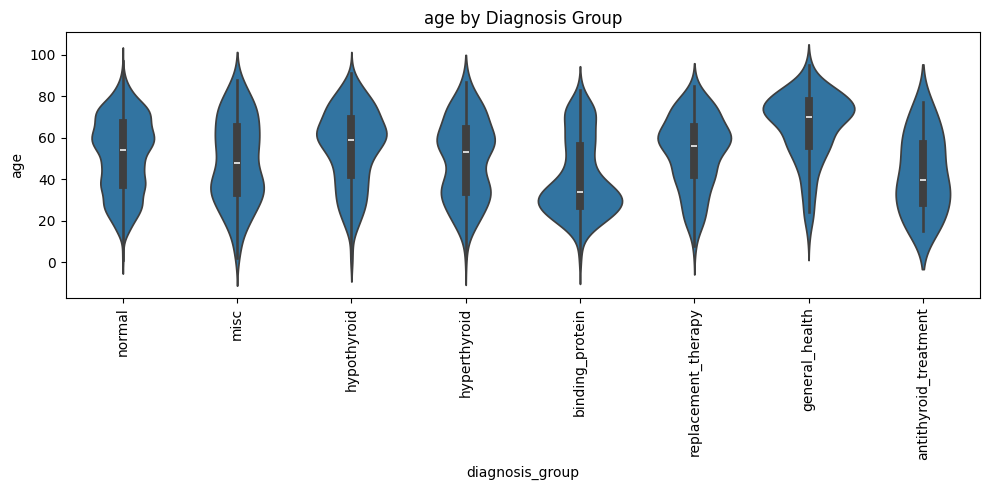

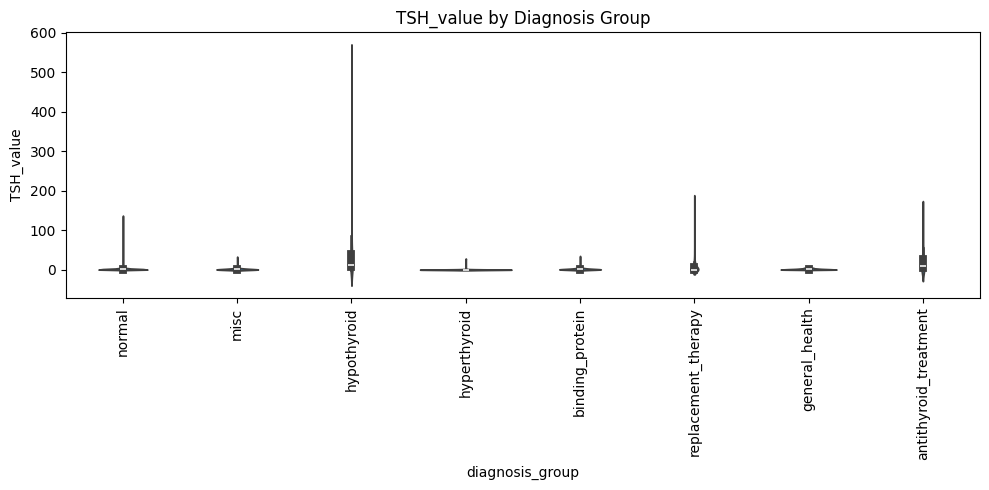

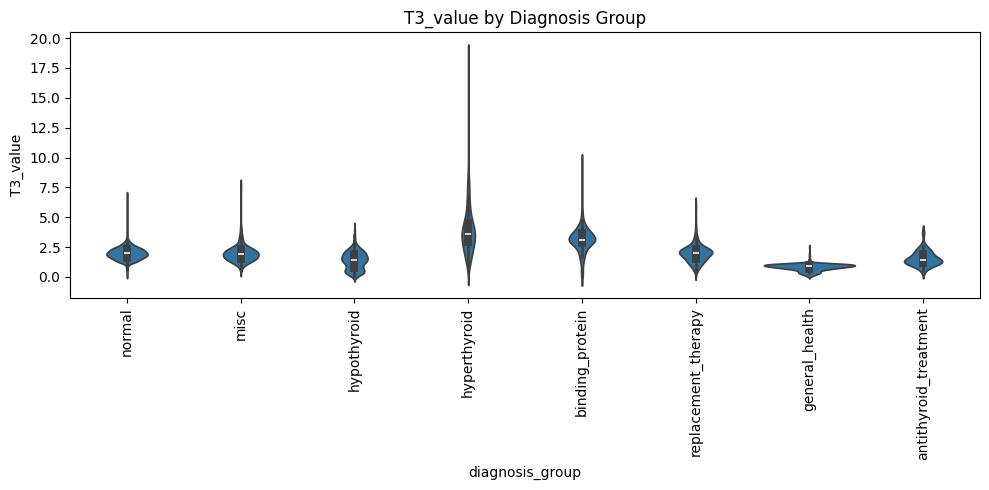

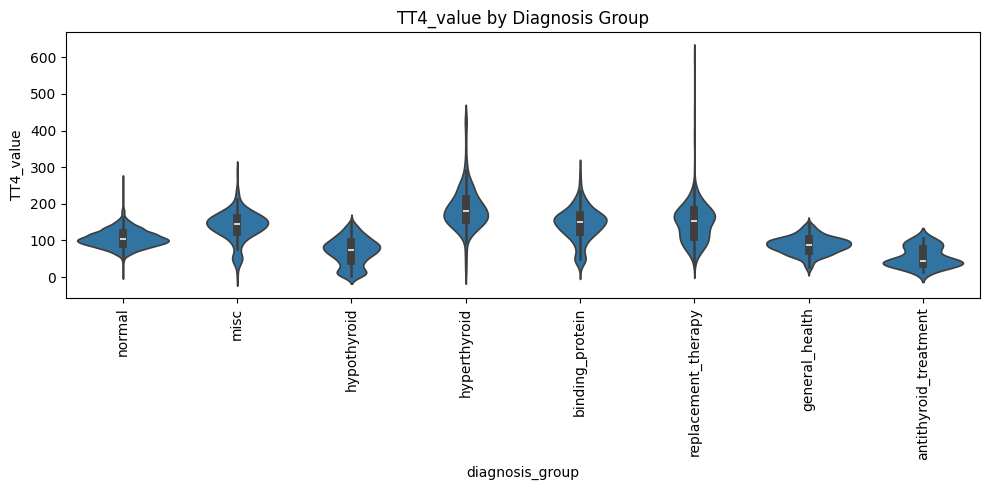

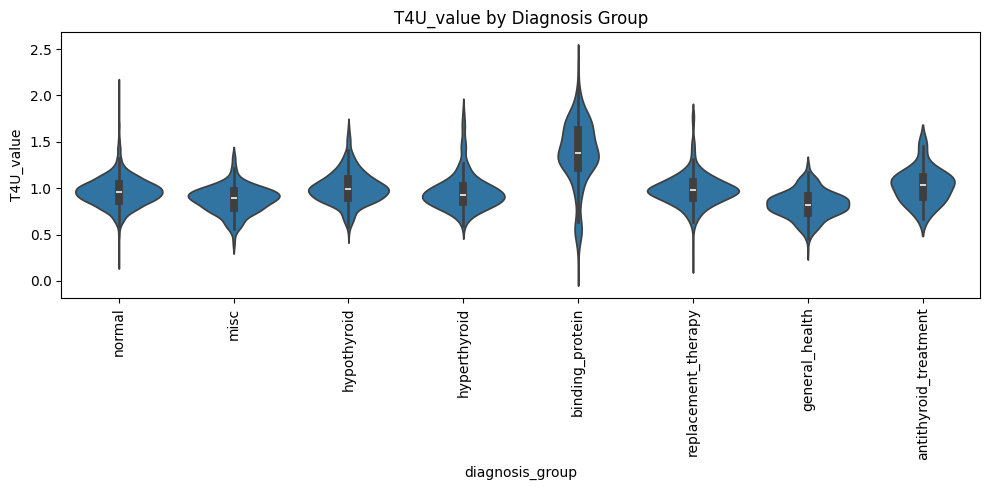

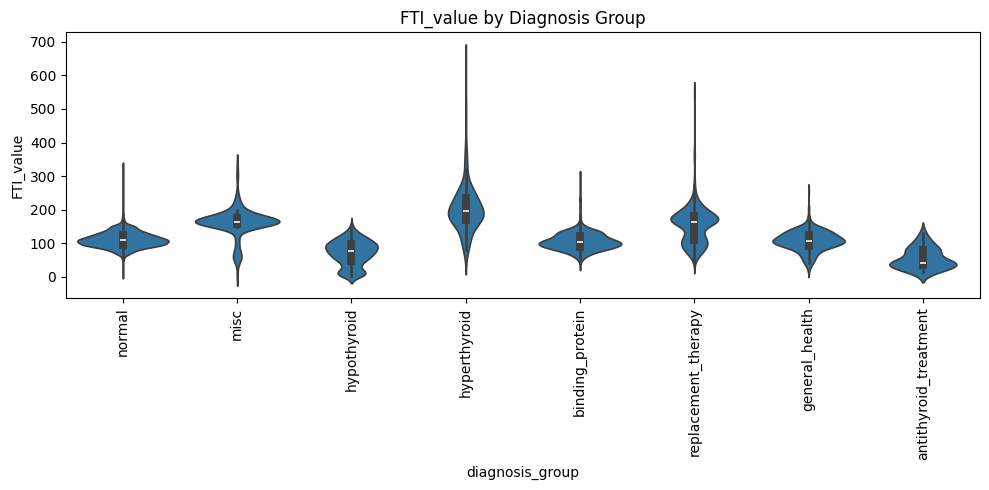

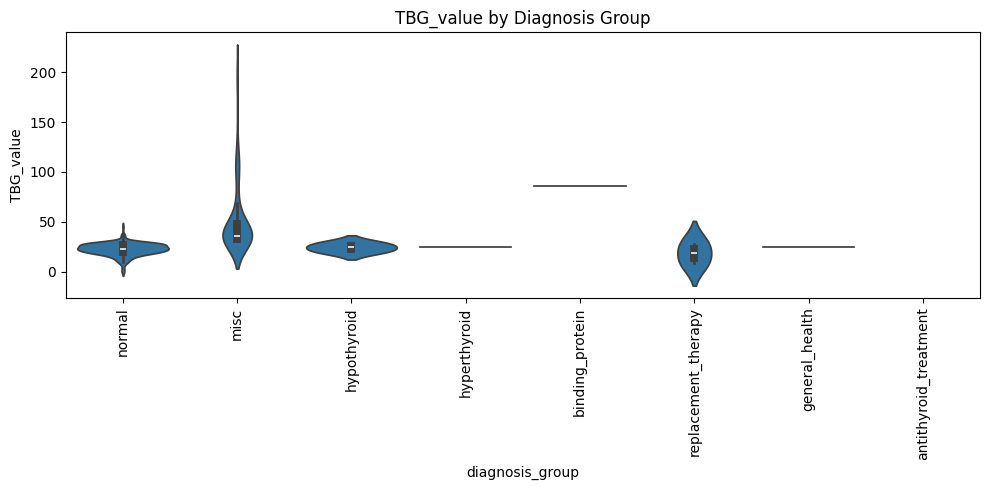

In [54]:
for col in numeric_features:
    violin_by_diag(df, col)

Age distributions show subtle differences across groups. Patients in the general health (reminder: other health conditions not healthy) group tend to skew older. The normal group reflects an average population pyramid. In contrast, individuals in binding protein and antithyroid treatment groups appear slightly younger on average, perhaps due to earlier onset or more proactive screening.

TSH clearly distinguishes the hypothyroid group, with values extending far beyond other diagnoses (consistent with TSH elevation in untreated or under-replaced hypothyroidism). In contrast, hyperthyroid and replacement therapy groups show significantly suppressed TSH, aligning with either endogenous hormone overproduction or exogenous suppression. Normal patients cluster tightly around the physiological baseline (around 1.5-2.5), confirming internal consistency.

T3_value spikes in the hyperthyroid group, forming a distinct, right-skewed distribution centered around elevated hormone levels, indicating thyrotoxicosis.

TT4_value behaves similarly, with hyperthyroid and replacement groups showing elevated values, while the hypothyroid group centers at the lower end of the range. The binding protein group also shows high TT4, likely due to increased TBG binding rather than true thyrotoxicosis.

T4U is markedly elevated in the binding protein group, fitting the clinical expectation that increased TBG levels raise T4U indirectly via competition.

FTI separates hyperthyroid and hypothyroid patients especially well. Hyperthyroid distributions are wide and right-skewed; hypothyroid ones are compressed and low. This makes FTI one of the strongest discriminators in the dataset.

TBG is especially high in the binding protein group (as expected), with minimal variance elsewhere.

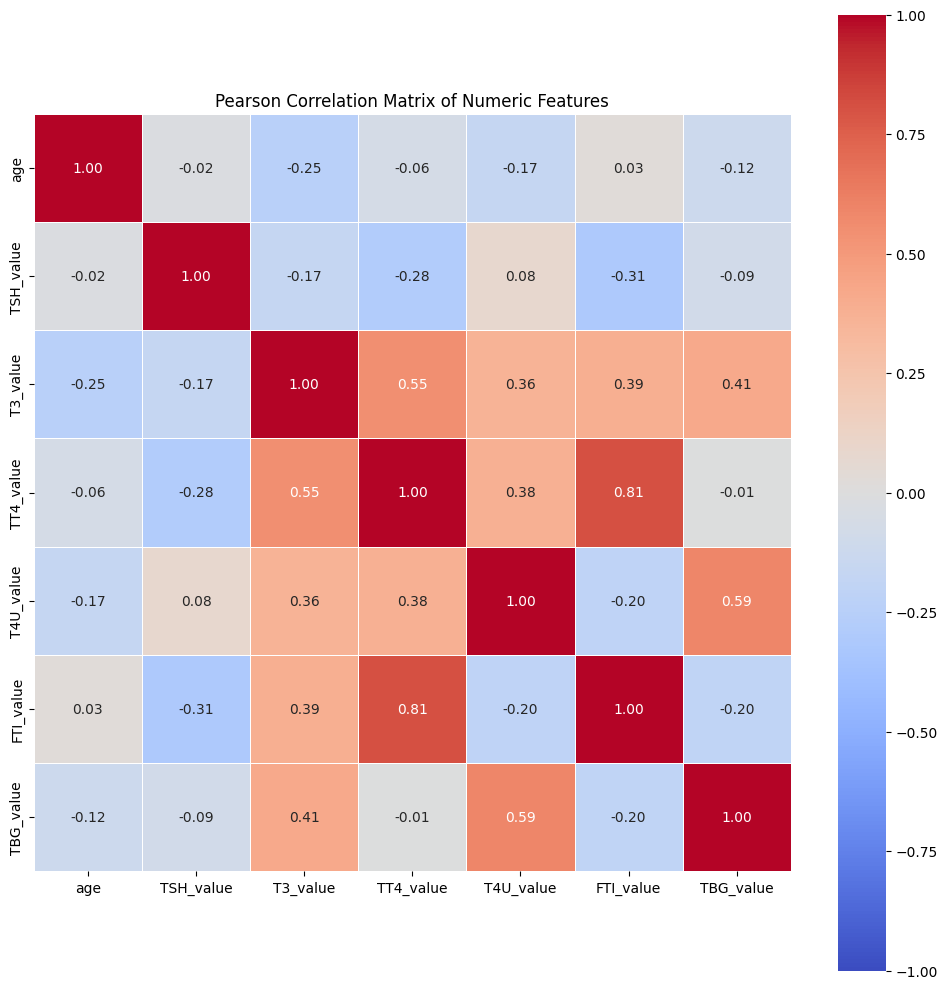

In [55]:
numeric_df = df[["age", "TSH_value", "T3_value", "TT4_value", "T4U_value", "FTI_value", "TBG_value"]]

corr = numeric_df.corr(method='pearson')

plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Pearson Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

- TT4_value and FTI_value (r = 0.81): As expected, Free Thyroxine Index is partially computed from TT4.
- TBG_value and T4U_value (r = 0.59): This reflects the binding effect — increased TBG leads to more T4 being bound and less free, which elevates the measured uptake.
- TT4_value and T3_value (r = 0.55): These are both thyroid hormones and typically elevate or depress together, depending on thyroid status.

In [60]:
sns.pairplot(df, hue="diagnosis_group", corner=True, plot_kws={"alpha": 0.4})
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

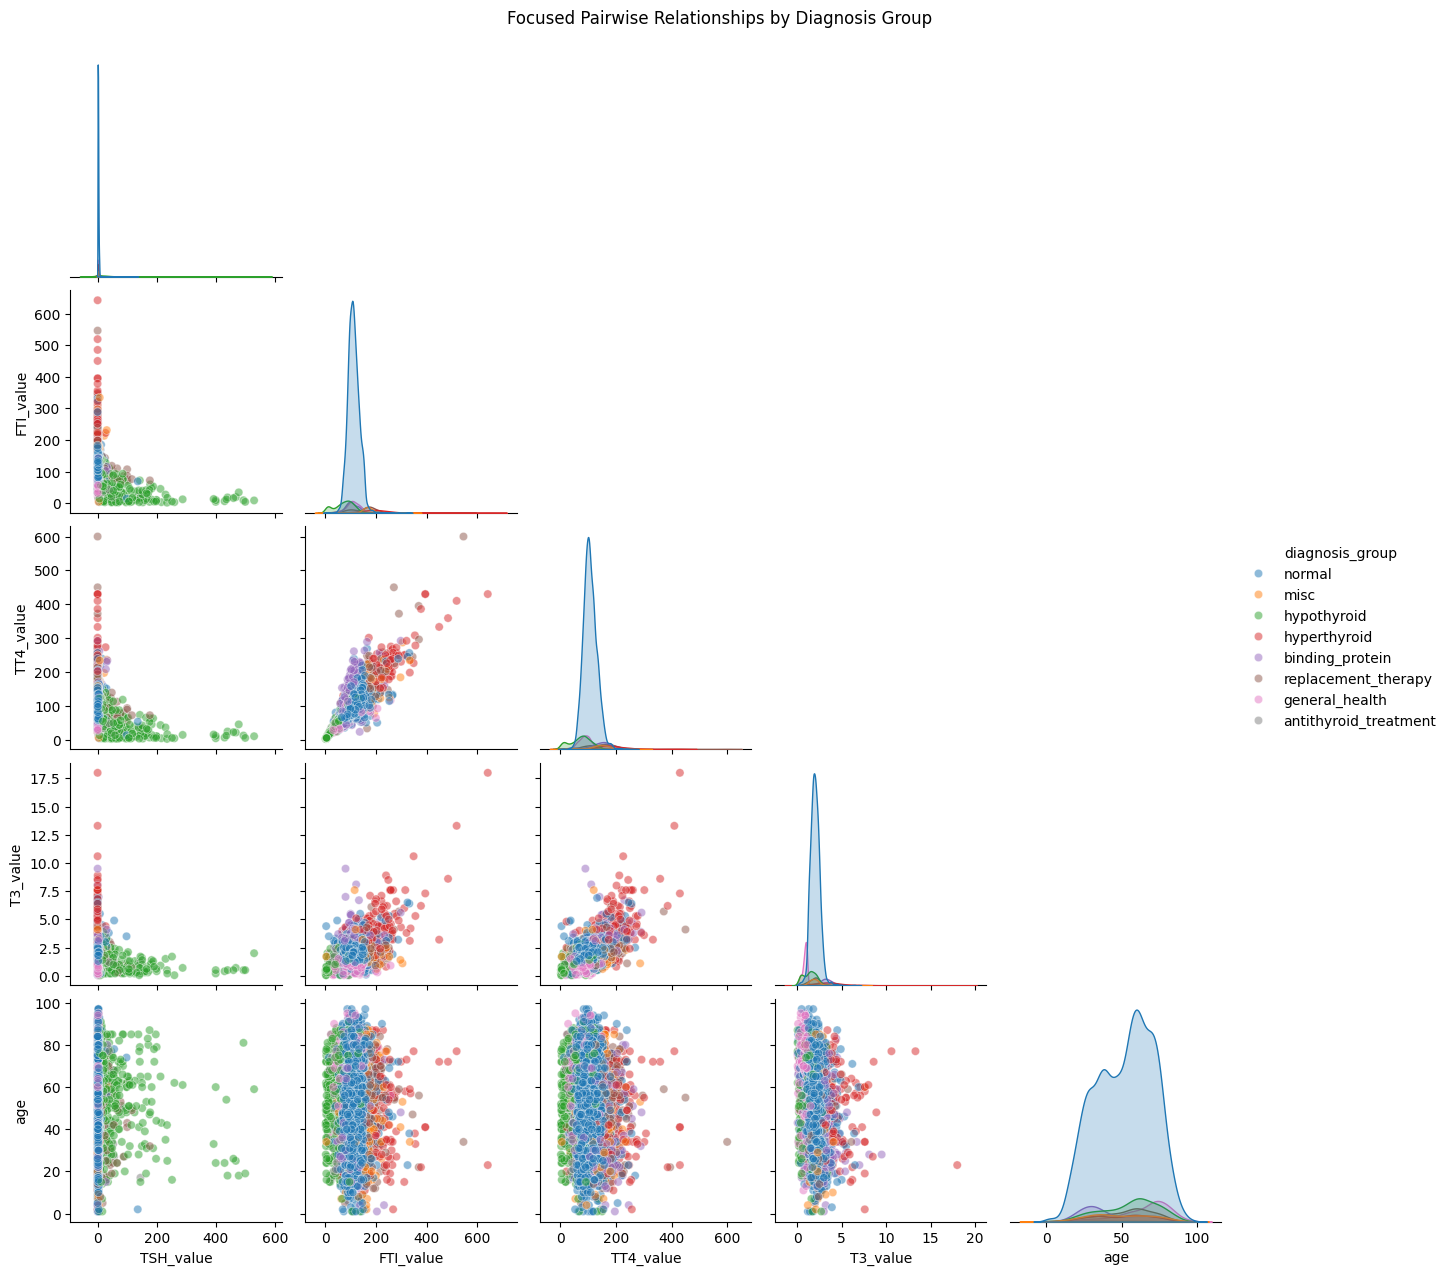

In [59]:
sns.pairplot(df, vars=["TSH_value", "FTI_value", "TT4_value", "T3_value", "age"],
             hue="diagnosis_group", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Focused Pairwise Relationships by Diagnosis Group", y=1.02)
plt.show()

- TSH vs FTI shows an excellent inverse relationship and clean separation between hypothyroid (high TSH, low FTI), hyperthyroid (low TSH, high FTI), and normal patients (tight cluster around baseline values). This mirrors the classic negative feedback loop of the thyroid axis.
- FTI vs TT4 reveals strong linear alignment, particularly among hyperthyroid and replacement therapy groups, confirming the composite nature of FTI.
- TT4 and T3 track closely in hyperthyroid and replacement categories, with a wider spread in normal and hypothyroid cases, reflecting differential T4 to T3 conversion.
- Age shows partial clustering, as patients in general health or replacement therapy groups trend older, while binding protein variations or treatment groups are more evenly distributed.

In [63]:
groups = df["diagnosis_group"].unique()
results = []

for feature in numeric_features:
    samples = [df[df["diagnosis_group"] == group][feature].dropna() for group in groups]
    stat, pval = f_oneway(*samples)
    results.append({"feature": feature, "F_statistic": stat, "p_value": pval})

anova_df = pd.DataFrame(results).sort_values("p_value")
display(anova_df)

C:\Users\Mar\AppData\Local\Temp\ipykernel_1064\4242757531.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = f_oneway(*samples)


,feature,F_statistic,p_value
1,TSH_value,300.124924,0.000000e+00
2,T3_value,528.790126,0.000000e+00
3,TT4_value,598.314897,0.000000e+00
4,T4U_value,322.943315,0.000000e+00
5,FTI_value,633.250262,0.000000e+00
0,age,56.406518,1.962576e-79
6,TBG_value,NaN,NaN


All continuous features except TBG_value showed statistically significant differences across diagnosis groups (p < 0.001), confirming their diagnostic value.

In [64]:
chi2_results = []

for col in bool_features:
    contingency = pd.crosstab(df[col], df["diagnosis_group"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        "feature": col,
        "chi2_stat": chi2,
        "p_value": p
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("p_value")
display(chi2_df)

,feature,chi2_stat,p_value
0,on_thyroxine,2191.532276,0.000000e+00
4,pregnant,850.509871,2.326645e-179
5,thyroid_surgery,388.848747,5.867586e-80
2,on_antithyroid_medication,265.110665,1.677155e-53
8,query_hyperthyroid,257.666651,6.461531e-52
14,sex_M,169.252556,3.608506e-33
7,query_hypothyroid,123.305471,1.568699e-23
11,tumor,80.096292,1.316606e-14
13,psych,63.417594,3.125343e-11
3,sick,49.820093,1.566841e-08


Several Boolean features demonstrated statistically significant associations with diagnostic groupings based on chi-squared tests. Notably, on_thyroxine, pregnant, and thyroid_surgery stood out with extremely high chi-squared statistics and p-values approaching zero, indicating strong relationships with specific thyroid conditions. Flags such as query_hyperthyroid, on_antithyroid_medication, and sex_M also contributed meaningfully to diagnostic separation.

On the other hand, features like goitre, lithium, and hypopituitary showed weaker associations, suggesting either more heterogeneous clinical presentations or limited diagnostic impact in this dataset. While these variables may still be relevant in nuanced cases, they offer less overall discriminatory power compared to the top-performing flags.

# HOLA GUAPOS US DEIXO AQUI TOT, PCA NO HE FET PQ CONSIDERO Q SI LA VOLEU JA LA FAREU, ESTÀ TOT BASTANT REDACTAT ACADÈMIC PER PODER FER COPY+PASTE DE LO QUE VULGUEM POSAR AL PAPER COM A TAL (falta posar referències de coses mèdiques q he posat pq la wikipedia i demés q tenia oberts no colen @david amb el teu amic chat), LES GRÀFIQUES PEL PAPER LES FARÉ EXPRESSAMENT SEGONS EL QUE VULGUEM POSAR I L'ESTIL QUE FACEM LES ALTRES <3